In [ ]:
import copy
import prior
from ai2thor.controller import Controller
from PIL import Image

# dataset = prior.load_dataset("procthor-10k")
dataset = prior.load_dataset("procthor-10k")

[AI2-THOR WARNING] There has been an update to ProcTHOR-10K that must be used with AI2-THOR version 5.0+. To use the new version of ProcTHOR-10K, please update AI2-THOR to version 5.0+ by running:
    pip install --upgrade ai2thor
Alternatively, to downgrade to the old version of ProcTHOR-10K, run:
   prior.load_dataset("procthor-10k", revision="ab3cacd0fc17754d4c080a3fd50b18395fae8647")


Loading test:  77%|████████████████████████████████████████████████████████████████████████████▏                      | 770/1000 [00:00<00:00, 7688.39it/s]

In [ ]:
house = dataset["train"][9]

In [ ]:
from egg.graph.egg import EGG
from egg.graph.spatial import SpatialComponents
from egg.graph.node import ObjectNode, Ai2ThorObjectMetadata
from egg.utils.geometry import Position, AxisAlignedBoundingBox
from egg.ai2thor_interface.event_simulator import EventSimulator
from egg.utils.geometry import Position, AxisAlignedBoundingBox, Dimensions
import egg.ai2thor_interface.navigation as nav
import copy

def get_top_down_frame():
    # Setup the top-down camera
    event = controller.step(action="GetMapViewCameraProperties", raise_for_failure=True)
    pose = copy.deepcopy(event.metadata["actionReturn"])

    bounds = event.metadata["sceneBounds"]["size"]
    max_bound = max(bounds["x"], bounds["z"])

    pose["fieldOfView"] = 50
    pose["position"]["y"] += 1.1 * max_bound
    pose["orthographic"] = False
    pose["farClippingPlane"] = 50
    del pose["orthographicSize"]

    # add the camera to the scene
    event = controller.step(
        action="AddThirdPartyCamera",
        **pose,
        skyboxColor="white",
        raise_for_failure=True,
    )
    top_down_frame = event.third_party_camera_frames[-1]
    return Image.fromarray(top_down_frame)



In [4]:
controller = Controller(
    agentMode="default",
    visibilityDistance=1.5,
    scene=house,
    gpu_device=0,
    # step sizes
    gridSize=0.5,
    snapToGrid=True,
    rotateStepDegrees=90,
    # image modalities
    renderDepthImage=True,
    renderInstanceSegmentation=True,
    # camera properties
    width=300,
    height=300,
    fieldOfView=90,
)

In [5]:
controller.reset(
    agentMode="default",
    visibilityDistance=1.5,
    scene=house,
    gpu_device=0,
    # step sizes
    gridSize=0.25,
    snapToGrid=True,
    rotateStepDegrees=90,
    # image modalities
    renderDepthImage=True,
    renderInstanceSegmentation=True,
    # camera properties
    width=300,
    height=300,
    fieldOfView=90,
)

<ai2thor.server.Event at 0x7527730448d0
    .metadata["lastAction"] = CreateHouse
    .metadata["lastActionSuccess"] = True
    .metadata["errorMessage"] = "
    .metadata["actionReturn"] = None
>

In [5]:
agent_metadata = controller.last_event.metadata["agent"]
objects = controller.last_event.metadata["objects"]
egg = EGG.from_ai2thor(ai2thor_agent_metadata=agent_metadata, ai2thor_house_metadata=house, ai2thor_object_metadata=objects, object_types_config_file="../../egg/configs/ai2-thor/object_type_config.toml")
event_simulator = EventSimulator(ai2thor_controller=controller, egg=egg)

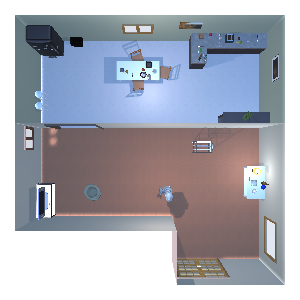

In [6]:
get_top_down_frame()

In [7]:
event_simulator.execute_pick(pick_object_name="Apple|surface|2|3")

2026-04-29 15:14:59,796 - egg.ai2thor_interface.event_simulator - [WARNING]: Unable to pick up Apple|surface|2|3 at x=4.5 y=0.9009997844696045 z=6.5, standing
2026-04-29 15:15:00,468 - egg.ai2thor_interface.event_simulator - [INFO]: Successfully picked up Apple|surface|2|3 at x=5.5 y=0.9009997844696045 z=7.0, standing
INFO:egg.ai2thor_interface.event_simulator:Successfully picked up Apple|surface|2|3 at x=5.5 y=0.9009997844696045 z=7.0, standing


True

In [ ]:
event_simulator.execute_place(held_object="Apple|surface|2|3", receptacle_object_name="Bowl|surface|3|42")

2026-04-29 15:15:05,083 - egg.ai2thor_interface.event_simulator - [WARNING]: Unable to place Apple|surface|2|3 at Bowl|surface|3|42 at x=8.0 y=0.9009997844696045 z=4.0, standing, retrying
2026-04-29 15:15:05,624 - egg.ai2thor_interface.event_simulator - [WARNING]: Unable to place Apple|surface|2|3 at Bowl|surface|3|42 at x=8.5 y=0.9009997844696045 z=4.5, standing, retrying
2026-04-29 15:15:06,236 - egg.ai2thor_interface.event_simulator - [WARNING]: Unable to place Apple|surface|2|3 at Bowl|surface|3|42 at x=8.0 y=0.9009997844696045 z=4.0, standing, retrying
2026-04-29 15:15:06,800 - egg.ai2thor_interface.event_simulator - [WARNING]: Unable to place Apple|surface|2|3 at Bowl|surface|3|42 at x=8.5 y=0.9009997844696045 z=4.0, standing, retrying
2026-04-29 15:15:07,170 - egg.ai2thor_interface.event_simulator - [WARNING]: Unable to place Apple|surface|2|3 at Bowl|surface|3|42 at x=8.5 y=0.9009997844696045 z=4.0, standing, retrying
2026-04-29 15:15:07,670 - egg.ai2thor_interface.event_simula

In [15]:
event_simulator.get_object_state(object_name="Apple|surface|2|3")

ObjectState(is_visible=False, position=Position(x=0.699, y=0.668, z=9.122), bounding_box=AxisAlignedBoundingBox(center=Position(x=0.699, y=0.668, z=9.122), size=Dimensions(x=0.129, y=0.141, z=0.129)), is_picked_up=False, is_moving=False, is_toggled=False, is_broken=False, is_filled_with_liquid=False, is_dirty=False, is_used_up=False, is_cooked=False, is_sliced=False, is_open=False, temperature='Cold', parent_receptacles=['Floor', 'Fridge|2|1'], receptacle_object_ids=None, instance_view=None, openness=0.0)

In [61]:
controller.last_event.metadata["agent"]

{'name': 'agent',
 'position': {'x': 0.25, 'y': 0.9009993672370911, 'z': 8.5},
 'rotation': {'x': 0.0, 'y': -1.9318693375680596e-05, 'z': 0.0},
 'cameraHorizon': 30.000003814697266,
 'isStanding': False,
 'inHighFrictionArea': False}

In [34]:
controller.step(action="Crouch")

<ai2thor.server.Event at 0x75d0257bf410
    .metadata["lastAction"] = Crouch
    .metadata["lastActionSuccess"] = True
    .metadata["errorMessage"] = "
    .metadata["actionReturn"] = None
>

In [25]:
controller.step(action="Stand")

<ai2thor.server.Event at 0x75d02872bd90
    .metadata["lastAction"] = Stand
    .metadata["lastActionSuccess"] = True
    .metadata["errorMessage"] = "
    .metadata["actionReturn"] = None
>

In [35]:
controller.step(action="Done")

<ai2thor.server.Event at 0x75d0266cd1d0
    .metadata["lastAction"] = Done
    .metadata["lastActionSuccess"] = True
    .metadata["errorMessage"] = "
    .metadata["actionReturn"] = None
>

In [59]:
event = controller.step(
    action="OpenObject",
    objectId="Fridge|2|1",
    openness=1,
    forceAction=False
)

In [16]:
event = controller.step(
    action="CloseObject",
    objectId="Fridge|2|1",
    forceAction=False
)

In [43]:
objects = event_simulator.ai2thor_controller.last_event.metadata["objects"]

In [25]:
event = controller.step(action="Crouch")

In [26]:
event = controller.step(action="Stand")

In [15]:
event = controller.step(action="RotateLeft")
event = controller.step(action="Done")

In [174]:
event = controller.step(action="MoveBack")

In [254]:
event = controller.step(
    action="PickupObject",
    objectId="Apple|surface|2|3",
    forceAction=False,
    manualInteract=False
)

In [273]:
event = controller.step(
    action="PutObject",
    objectId="DiningTable|2|2|0",
    forceAction=False,
    placeStationary=True
)

In [239]:
event = controller.step(
    action="PlaceObjectAtPoint",
    objectId="Apple|surface|2|3",
    position={"x": 4.4925971031188965, "y": 0.8489766716957092, "z": 8.048712730407715},
)

In [18]:
event = controller.step(action="MoveAhead")
_ = controller.step(action="Done")

In [21]:
event = controller.step(action="MoveBack")
_ = controller.step(action="Done")

In [19]:
event = controller.step(action="RotateLeft")
_ = controller.step(action="Done")

In [52]:
event = controller.step(action="RotateRight")
_ = controller.step(action="Done")

In [67]:
event = controller.step(
    action="MoveHeldObjectLeft",
    moveMagnitude=0.1,
    forceVisible=False
)
_ = controller.step(action="Done")

In [20]:
event = controller.step(
    action="PutObject",
    objectId="Bowl|surface|3|42",
    forceAction=False,
    placeStationary=True
)
_ = controller.step(action="Done")

In [21]:
event

<ai2thor.server.Event at 0x7a9b0e5ce350
    .metadata["lastAction"] = PutObject
    .metadata["lastActionSuccess"] = False
    .metadata["errorMessage"] = "No valid positions to place object found
    .metadata["actionReturn"] = None
>

In [22]:
event = controller.step(
    action="GetSpawnCoordinatesAboveReceptacle",
    objectId="Bowl|surface|3|42",
    anywhere=False
)
spawnable_loc = event.metadata["actionReturn"]

In [25]:
for loc in spawnable_loc:
    event = controller.step(
        action="PlaceObjectAtPoint",
        objectId="Apple|surface|2|3",
        position=loc,
    )
    print(event)
    if event.metadata["lastActionSuccess"]:
        break

<ai2thor.server.Event at 0x7a9b0e146ed0
    .metadata["lastAction"] = PlaceObjectAtPoint
    .metadata["lastActionSuccess"] = False
    .metadata["errorMessage"] = "Spawn area not clear (Bowl|surface|3|42) is in the way), can't place object at that point
    .metadata["actionReturn"] = None
>
<ai2thor.server.Event at 0x7a9b0e1d2810
    .metadata["lastAction"] = PlaceObjectAtPoint
    .metadata["lastActionSuccess"] = False
    .metadata["errorMessage"] = "Spawn area not clear (Bowl|surface|3|42) is in the way), can't place object at that point
    .metadata["actionReturn"] = None
>
<ai2thor.server.Event at 0x7a9b0fef6790
    .metadata["lastAction"] = PlaceObjectAtPoint
    .metadata["lastActionSuccess"] = False
    .metadata["errorMessage"] = "Spawn area not clear (Bowl|surface|3|42) is in the way), can't place object at that point
    .metadata["actionReturn"] = None
>
<ai2thor.server.Event at 0x7a9b0e3ec090
    .metadata["lastAction"] = PlaceObjectAtPoint
    .metadata["lastActionSucc

In [26]:
controller.step(action="Done")

<ai2thor.server.Event at 0x7a9b0d58fa90
    .metadata["lastAction"] = Done
    .metadata["lastActionSuccess"] = True
    .metadata["errorMessage"] = "
    .metadata["actionReturn"] = None
>

In [28]:
controller.stop()